## **DAV Lab-4**
#### Name: Yashmi Patle
#### Section: A
#### Batch: A1
#### Roll No.: 15

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

#### Description:
#### The required Python libraries are imported for data manipulation, visualization, preprocessing, feature scaling, label encoding, and dataset splitting. These libraries provide the essential tools for building and evaluating the machine learning model.

In [ ]:
df=pd.read_csv("titanic.csv")

#### Description:
#### The Titanic dataset is loaded from the CSV file into a Pandas DataFrame named `df`. This dataset is used for data preprocessing, analysis, and machine learning model development.

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Description:
#### The first five rows of the Titanic dataset are displayed using the `head()` function. This provides a quick preview of the dataset's structure, features, and sample records.

In [ ]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


#### Description:
#### The last five rows of the Titanic dataset are displayed using the `tail()` function. This helps in examining the ending records and verifying the dataset's contents.

In [ ]:
df.shape

(891, 12)

#### Description:
#### The shape of the Titanic dataset is displayed, showing the total number of rows and columns. This provides an overview of the dataset's dimensions.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#### Description:
#### The `info()` function displays a summary of the Titanic dataset, including the column names, data types, non-null values, and memory usage. This helps in understanding the dataset's structure and identifying missing values.

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### Description:
#### The `describe()` function generates descriptive statistical summaries of the numerical features in the Titanic dataset. It displays measures such as count, mean, standard deviation, minimum, maximum, and quartile values.

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


#### Description:
#### The total number of missing values in each column of the Titanic dataset is calculated using the `isnull().sum()` function. This helps identify columns that require data cleaning or preprocessing.

In [ ]:
df["Embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

#### Description:
#### The unique values present in the `Embarked` column of the Titanic dataset are displayed. This helps identify the different embarkation locations and detect any missing or unexpected values.

In [ ]:
df["Embarked"]=df["Embarked"].replace("S",0)
df["Embarked"]=df["Embarked"].replace("C",1)
df["Embarked"]=df["Embarked"].replace("Q",2)

/tmp/ipykernel_1514/253371351.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Embarked"]=df["Embarked"].replace("Q",2)


#### Description:
#### The categorical values in the `Embarked` column are converted into numerical values by replacing `S`, `C`, and `Q` with `0`, `1`, and `2`, respectively. This encoding prepares the feature for use in machine learning models.

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,1.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,0.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,0.0


#### Description:
#### The first five rows of the updated Titanic dataset are displayed using the `head()` function. This verifies that the `Embarked` column has been successfully converted into numerical values.

In [ ]:
df["Age"].fillna(df["Age"].median(),inplace=True)

/tmp/ipykernel_1514/860536840.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(),inplace=True)


#### Description:
#### The missing values in the `Age` column are replaced with the median age of the dataset using the `fillna()` function. This data imputation technique handles missing values while minimizing the effect of outliers.

In [ ]:
df["Embarked"].fillna(df["Embarked"].mode()[0],inplace=True)

/tmp/ipykernel_1514/548196730.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0],inplace=True)


#### Description:
#### The missing values in the `Embarked` column are replaced with the most frequently occurring value (mode) using the `fillna()` function. This ensures that all missing categorical values are handled before model training.

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


#### Description:
#### The total number of missing values in each column of the Titanic dataset is displayed after data preprocessing. This verifies whether all missing values have been successfully handled.

In [ ]:
df.drop("Cabin",axis=1,inplace=True)

#### Description:
#### The `Cabin` column is removed from the Titanic dataset using the `drop()` function because it contains a large number of missing values. This simplifies the dataset and improves data quality for model training.

In [ ]:
df.duplicated().sum()

np.int64(0)

#### Description:
#### The total number of duplicate records in the Titanic dataset is calculated using the `duplicated().sum()` function. This helps identify duplicate entries that may need to be removed during data preprocessing.

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,1.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,0.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,0.0


#### Description:
#### The first five rows of the preprocessed Titanic dataset are displayed using the `head()` function. This provides a preview of the updated dataset after the data cleaning and preprocessing steps.

In [ ]:
df.drop_duplicated(inplace=True)

#### Description:
#### The duplicate records are removed from the Titanic dataset using the `drop_duplicates()` function. This ensures that each observation is unique and improves the quality of the dataset for further analysis and model training.

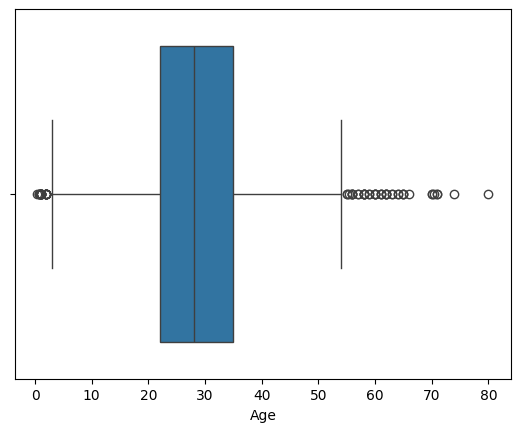

In [ ]:
sns.boxplot(x=df["Age"])
plt.show()

#### Description:
#### A box plot is created to visualize the distribution of the `Age` feature in the Titanic dataset. It helps identify the spread of the data, median, quartiles, and potential outliers.

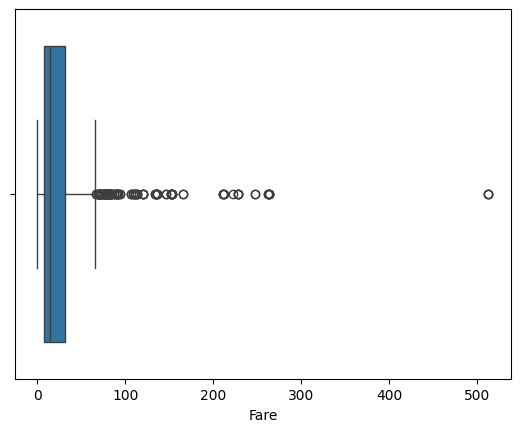

In [ ]:
sns.boxplot(x=df["Fare"])
plt.show()

#### Description:
#### A box plot is created to visualize the distribution of the `Fare` feature in the Titanic dataset. It helps identify the spread of fare values, median, quartiles, and potential outliers.

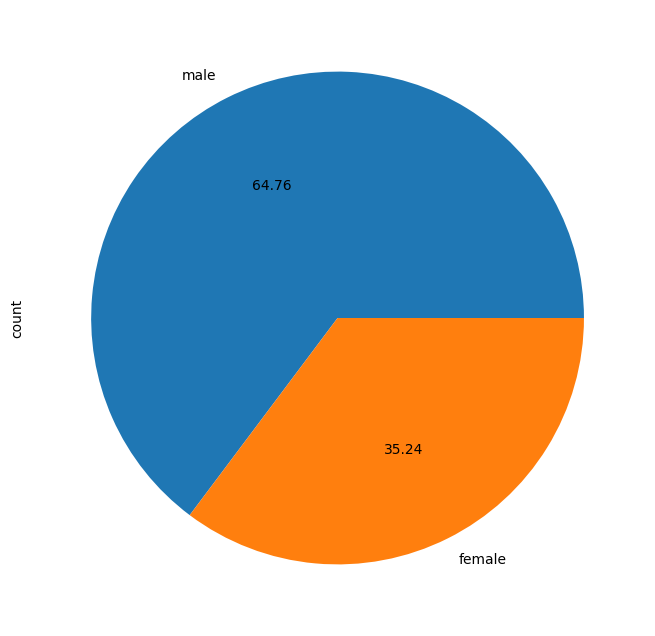

In [ ]:
plt.figure(figsize=(14,8))
df['Sex'].value_counts().plot(kind="pie",autopct="%.2f")
plt.show()

#### Description:
#### A pie chart is created to visualize the distribution of passengers based on the `Sex` feature in the Titanic dataset. The chart displays the percentage of each gender, providing an overview of the dataset's gender composition.

In [ ]:
Q1=df["Fare"].quantile(0.25)
Q3=df["Fare"].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
df=df[(df["Fare"]>=lower) & (df["Fare"]<=upper)]

#### Description:
#### The Interquartile Range (IQR) method is used to detect and remove outliers from the `Fare` column. Records with fare values outside the calculated lower and upper limits are excluded to improve the quality of the dataset.

In [ ]:
le=LabelEncoder()
df["Sex"]=le.fit_transform(df["Sex"])

/tmp/ipykernel_1514/3106616132.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Sex"]=le.fit_transform(df["Sex"])


#### Description:
#### The `LabelEncoder` is used to convert the categorical values in the `Sex` column into numerical labels. This transformation prepares the feature for use in machine learning models.

In [ ]:
df["Sex"]=df["Sex"].replace("male",0)
df["Sex"]=df["Sex"].replace("female",1)

/tmp/ipykernel_1514/2822182126.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Sex"]=df["Sex"].replace("female",1)


#### Description:
#### The categorical values in the `Sex` column are converted into numerical values by replacing `male` with `0` and `female` with `1`. This encoding prepares the feature for machine learning algorithms that require numerical input.

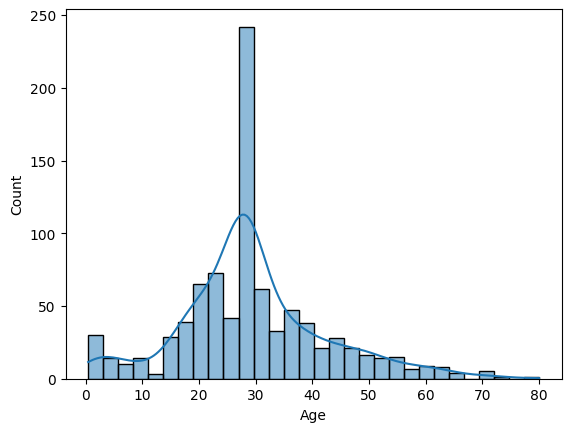

In [ ]:
sns.histplot(df["Age"],kde=True)
plt.show()

#### Description:
#### A histogram with a Kernel Density Estimation (KDE) curve is created to visualize the distribution of the `Age` feature in the Titanic dataset. This plot helps analyze the frequency distribution and density of passenger ages.

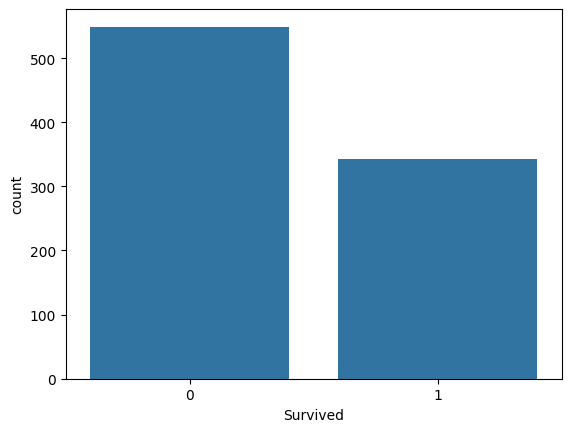

In [ ]:
sns.countplot(x="Survived",data=df)
plt.show()

#### Description:
#### A count plot is created to display the distribution of passengers based on the `Survived` feature in the Titanic dataset. It shows the number of passengers who survived and those who did not survive.

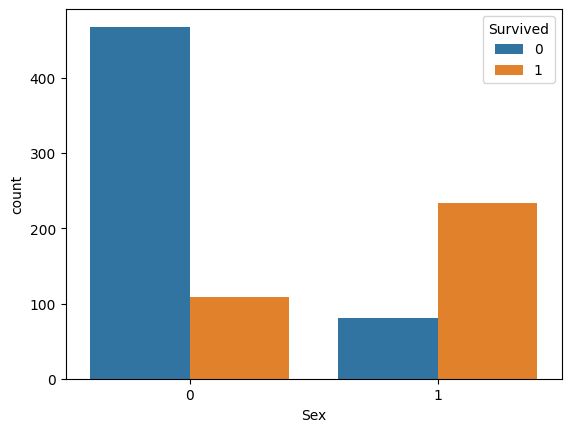

In [ ]:
sns.countplot(x="Sex",hue="Survived",data=df)
plt.show()

#### Description:
#### A count plot is created to visualize the relationship between the `Sex` and `Survived` features in the Titanic dataset. It compares the number of survivors and non-survivors for each gender.

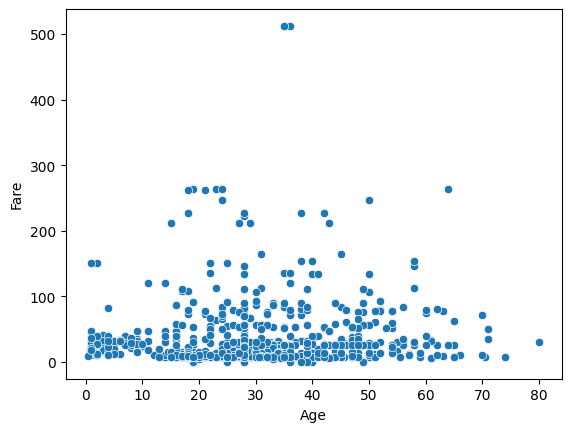

In [ ]:
sns.scatterplot(x="Age",y="Fare",data=df)
plt.show()

#### Description:
#### A scatter plot is created to visualize the relationship between the `Age` and `Fare` features in the Titanic dataset. This helps identify patterns, trends, and any possible correlation between passengers' ages and ticket fares.

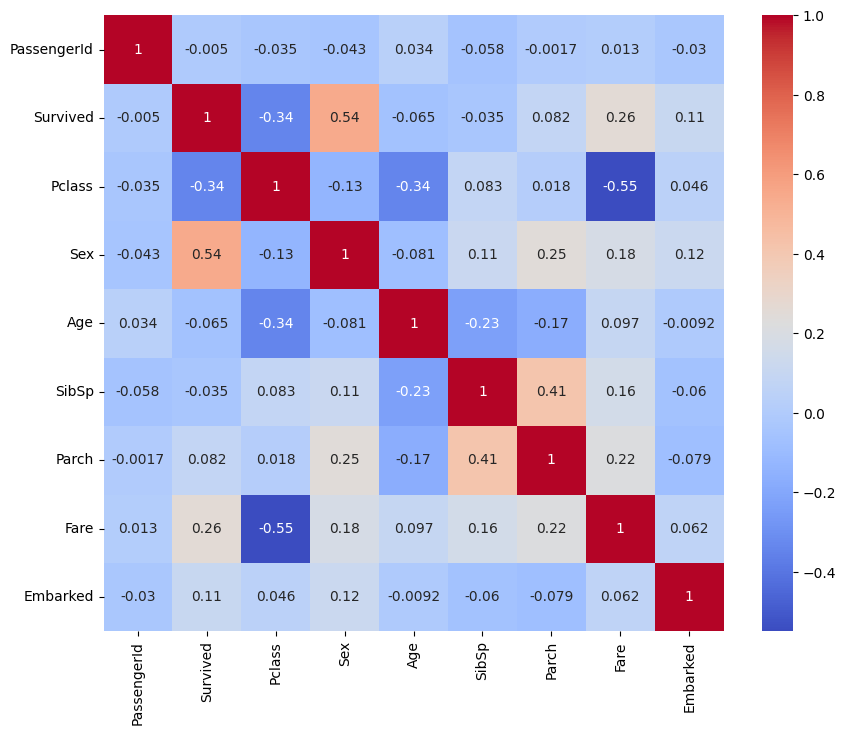

In [ ]:
plt.figure(figsize=(10,8))
numeric_df=df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')
plt.show()

#### Description:
#### A heatmap is created to visualize the correlation matrix of all numerical features in the Titanic dataset. The annotated correlation values help identify the strength and direction of relationships between numerical variables.

NameError: name 'show' is not defined

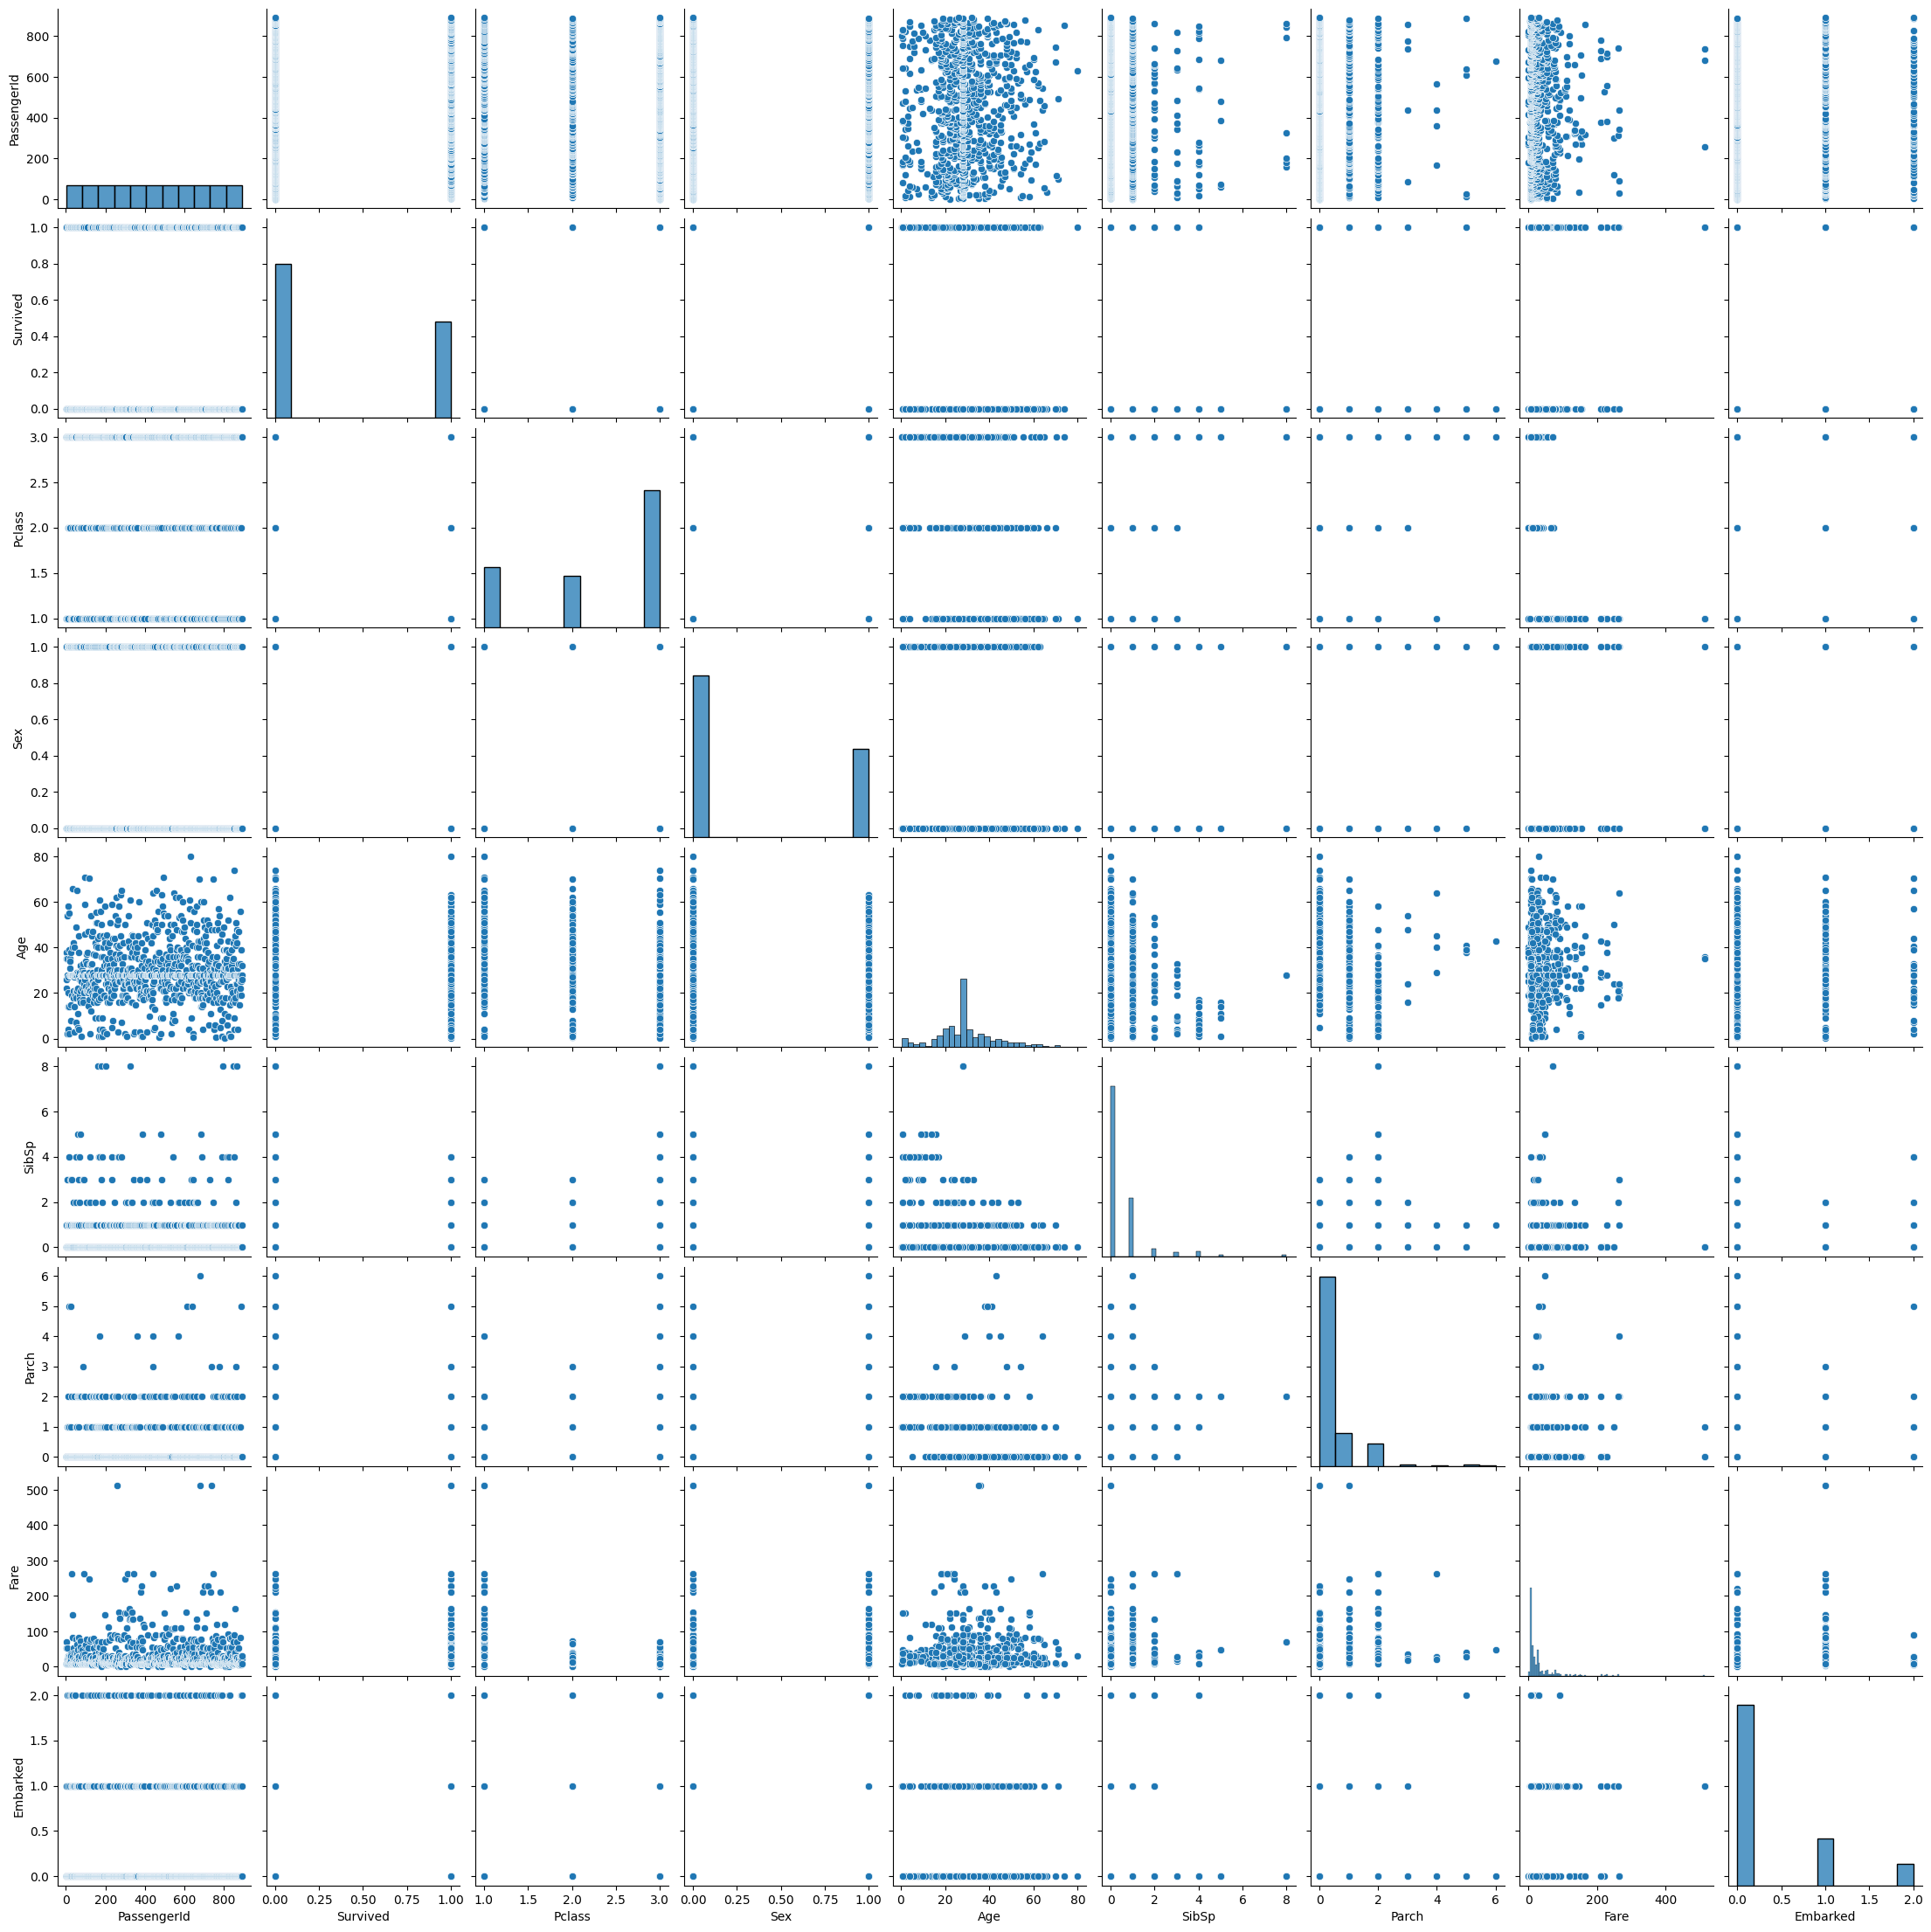

In [ ]:
sns.pairplot(df)
plt.show()

#### Description:
#### A pair plot is created to visualize the pairwise relationships among all features in the Titanic dataset. It displays scatter plots for feature combinations and distribution plots for individual features, helping identify patterns, correlations, and potential outliers.

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1.0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0.0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0.0


#### Description:
#### The first five rows of the fully preprocessed Titanic dataset are displayed using the `head()` function. This provides a final preview of the cleaned and transformed data before applying machine learning models.

In [ ]:
scalar=StandardScaler()
df[["Age","Fare"]]=scalar.fit_transform(df[["Age","Fare"]])

#### Description:
#### The `StandardScaler` is used to standardize the `Age` and `Fare` features by transforming them to have a mean of 0 and a standard deviation of 1. This feature scaling improves the performance of machine learning algorithms that are sensitive to differences in feature scales.

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,-0.565736,1,0,A/5 21171,-0.502445,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0.663861,1,0,PC 17599,0.786845,1.0
2,3,1,3,"Heikkinen, Miss. Laina",1,-0.258337,0,0,STON/O2. 3101282,-0.488854,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0.433312,1,0,113803,0.420730,0.0
4,5,0,3,"Allen, Mr. William Henry",0,0.433312,0,0,373450,-0.486337,0.0


#### Description:
#### The first five rows of the standardized Titanic dataset are displayed using the `head()` function. This verifies that the `Age` and `Fare` features have been successfully scaled and the dataset is ready for machine learning model training.

In [ ]:
X=df.drop("Survived",axis=1)
y=df["Survived"]

#### Description:
#### The dataset is divided into features (`X`) and the target variable (`y`). The `Survived` column is assigned as the target variable, while all remaining columns are used as input features for training the machine learning model.

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

#### Description:
#### The dataset is split into training and testing sets using the `train_test_split()` function. Here, 80% of the data is used for training the model, while 20% is reserved for testing. The `random_state=42` parameter ensures that the data split is reproducible.

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 7)
(179, 7)
(712,)
(179,)


#### Description:
#### The shapes of the training and testing feature sets (`X_train`, `X_test`) and target sets (`y_train`, `y_test`) are displayed. This verifies that the dataset has been correctly split into training and testing subsets for model development and evaluation.